# OS Analysis

**This notebook analyzes overall survival in patients with advanced non-small cell lung cancer and high PDL1 treated with first-line pembrolizumab plus platinum-based chemotherapy or pembrolizumab.** 

In [1]:
import numpy as np
import pandas as pd

from iptw_survival import IPTWSurvivalEstimator

import matplotlib.pyplot as plt
from lifelines.plotting import add_at_risk_counts

from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

## Import data

In [2]:
treatment_df = pd.read_csv('../outputs/pembrochemo_pembro_index.csv')

In [3]:
treatment_df.sample(3)

,PatientID,LineName,StartDate
6103,F32717C4BEFAA,pembro_platinum,2024-12-12
6606,F3742A9E916E6,pembro_platinum,2023-05-19
12915,F71A750E2E28C,pembro_platinum,2021-05-19


In [4]:
treatment_df.shape

(20623, 3)

In [5]:
treatment_df['treatment'] = (treatment_df['LineName'] == 'pembro_platinum').astype(int)

In [6]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [7]:
features_df.shape

(2064, 164)

In [8]:
df = pd.merge(features_df, treatment_df, on = 'PatientID', how = 'left')

In [9]:
df.shape

(2064, 167)

In [10]:
df = df.query('adv_diagnosis_year <= 2023')

In [11]:
df.shape

(1681, 167)

## Survival analysis with IPTW

In [12]:
df.treatment.value_counts()

treatment
0    1096
1     585
Name: count, dtype: int64

In [13]:
# Percent censoring
(
    df.groupby('treatment')['event']
    .apply(lambda x: (x == 0).mean())
)

treatment
0    0.283759
1    0.377778
Name: event, dtype: float64

In [14]:
estimator = IPTWSurvivalEstimator()

In [15]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['Histology', 'SmokingStatus'],
              cont_var = ['days_diagnosis_to_adv', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'percent_change_weight', 'hemoglobin', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'ecog_index_na', 'ses_mod_na', 'medicaid', 'before_2020', 'days_to_treatment_before_30d'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = True,
              use_missing_flags = False)

In [16]:
iptw_df = estimator.transform()

In [17]:
ps_fig = estimator.propensity_score_plot(bins = 30)

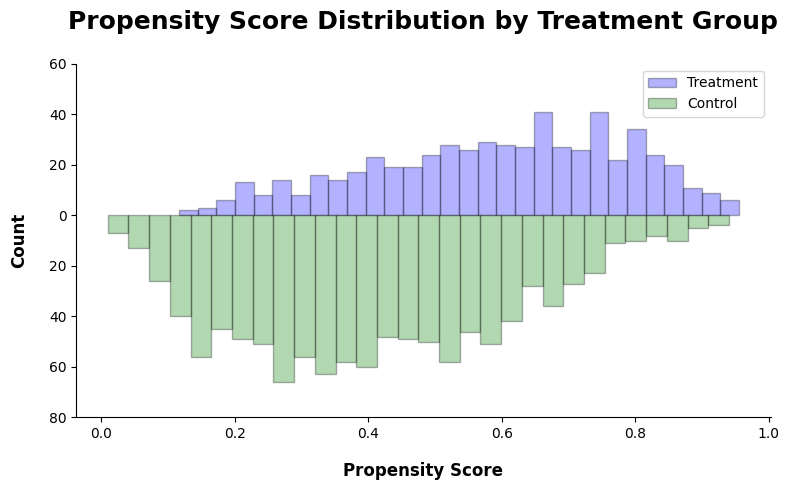

In [18]:
ps_fig

In [19]:
smd_df, smd_fig = estimator.standardized_mean_differences(return_fig = True)

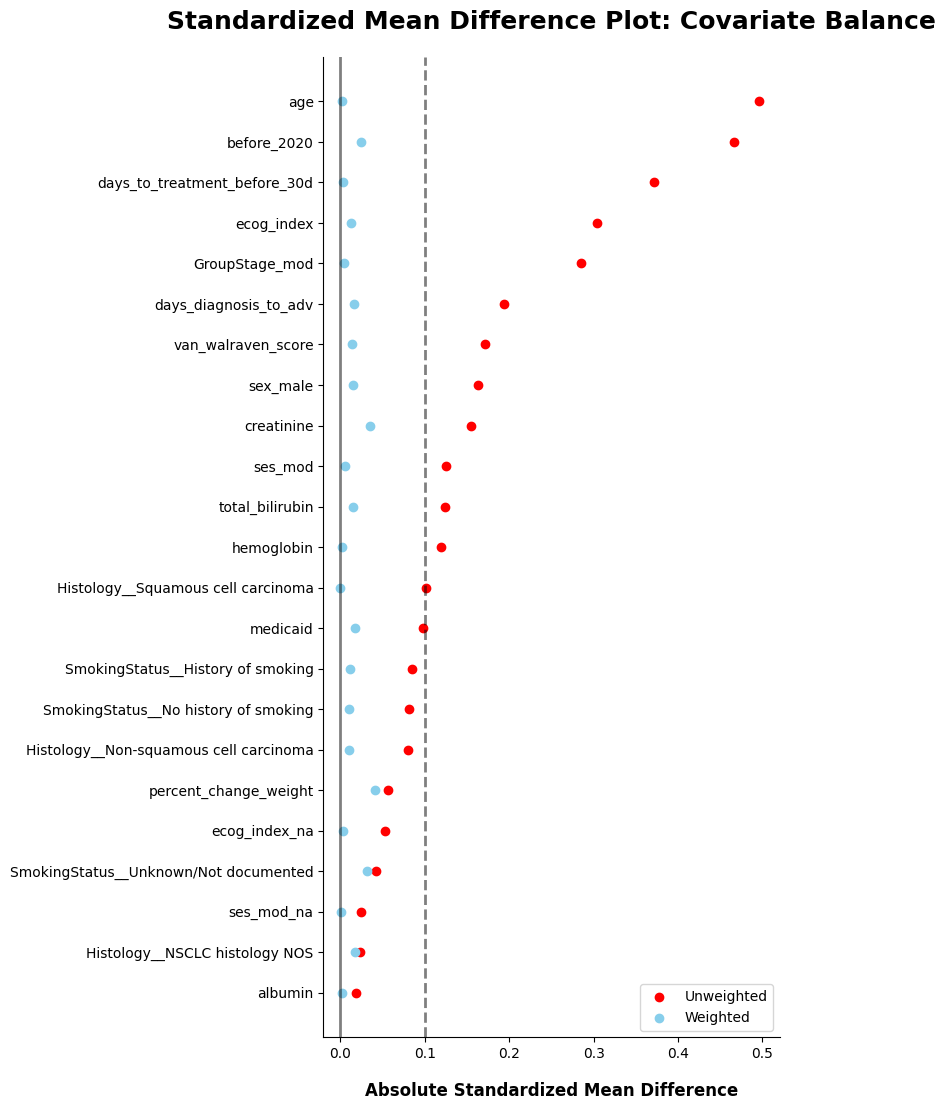

In [20]:
smd_fig

In [21]:
km_confidence_intervals_df = estimator.km_confidence_intervals(df = iptw_df,
                                                               duration_col = 'duration',
                                                               event_col = 'event',
                                                               weight_col = 'iptw',
                                                               n_bootstrap = 1000,
                                                               random_state = 42,
                                                               n_jobs = -1)

In [22]:
results = estimator.survival_metrics(df = iptw_df,
                                     duration_col = 'duration',
                                     event_col = 'event',
                                     weight_col = 'iptw',
                                     psurv_time_points = [180, 365, 730, 1095],
                                     rmst_time_points = [180, 365, 730, 1095],
                                     median_time = True,
                                     n_bootstrap = 1000,
                                     random_state = 42,
                                     n_jobs = -1)

In [23]:
# Median results
print('Median survival results')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x / 30, 1) for x in results['treatment']['median'])} months')
print(f'Pembrolizumab: {tuple(round(x / 30, 1) for x in results['control']['median'])} months')
print(f'Difference: {tuple(round(x / 30, 1) for x in results['difference']['median'])} months')

Median survival results
Pembrolizumab plus chemotherapy: (20.9, 17.0, 24.0) months
Pembrolizumab: (16.8, 14.0, 20.0) months
Difference: (4.1, -1.4, 8.3) months


In [24]:
print('RMST results at 6 months')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][180])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][180])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][180])} days')

print('')
print('RMST results at 1 year')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][365])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][365])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][365])} days')

print('')
print('RMST results at 2 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][730])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][730])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][730])} days')

print('')
print('RMST results at 3 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 1) for x in results['treatment']['rmst'][1095])} days')
print(f'Pembrolizumab: {tuple(round(x, 1) for x in results['control']['rmst'][1095])} days')
print(f'Difference: {tuple(round(x, 1) for x in results['difference']['rmst'][1095])} days')

RMST results at 6 months
Pembrolizumab plus chemotherapy: (156.5, 151.8, 161.1) days
Pembrolizumab: (147.4, 143.3, 151.4) days
Difference: (9.1, 3.1, 15.3) days

RMST results at 1 year
Pembrolizumab plus chemotherapy: (285.2, 273.7, 297.1) days
Pembrolizumab: (266.9, 257.4, 276.7) days
Difference: (18.4, 3.2, 32.9) days

RMST results at 2 years
Pembrolizumab plus chemotherapy: (481.1, 453.7, 506.1) days
Pembrolizumab: (445.0, 425.8, 466.3) days
Difference: (36.1, 3.0, 67.8) days

RMST results at 3 years
Pembrolizumab plus chemotherapy: (626.9, 585.5, 666.0) days
Pembrolizumab: (584.4, 553.4, 615.8) days
Difference: (42.5, -7.4, 89.6) days


In [25]:
print('Probability of survival at 6 months')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][180])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][180])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][180])}')

print('')
print('Probability of survival at 1 year')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][365])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][365])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][365])}')

print('')
print('Probability of survival at 2 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][730])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][730])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][730])}')

print('')
print('Probability of survival at 3 years')
print(f'Pembrolizumab plus chemotherapy: {tuple(round(x, 3) for x in results['treatment']['survival_prob'][1095])}')
print(f'Pembrolizumab: {tuple(round(x, 3) for x in results['control']['survival_prob'][1095])}')
print(f'Difference: {tuple(round(x, 3) for x in results['difference']['survival_prob'][1095])}')

Probability of survival at 6 months
Pembrolizumab plus chemotherapy: (0.77, 0.729, 0.81)
Pembrolizumab: (0.715, 0.683, 0.748)
Difference: (0.055, 0.004, 0.106)

Probability of survival at 1 year
Pembrolizumab plus chemotherapy: (0.625, 0.579, 0.671)
Pembrolizumab: (0.578, 0.543, 0.614)
Difference: (0.047, -0.011, 0.103)

Probability of survival at 2 years
Pembrolizumab plus chemotherapy: (0.45, 0.403, 0.496)
Pembrolizumab: (0.426, 0.39, 0.463)
Difference: (0.024, -0.031, 0.079)

Probability of survival at 3 years
Pembrolizumab plus chemotherapy: (0.366, 0.322, 0.412)
Pembrolizumab: (0.339, 0.305, 0.375)
Difference: (0.028, -0.03, 0.082)


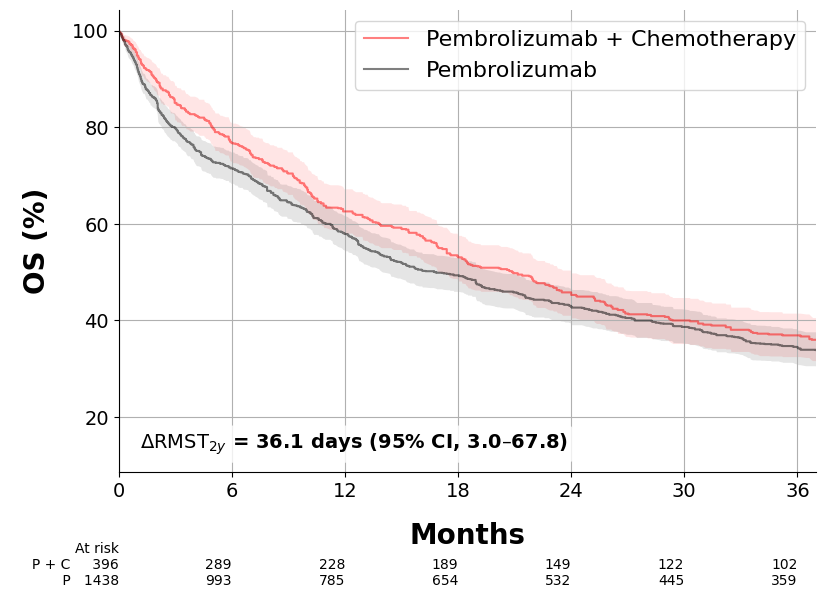

In [26]:
fig = plt.figure(figsize=(9, 6))
ax = plt.gca()

# pembro + chemo estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.treatment_estimate * 100, 
        color='red', 
        alpha=0.5,
        label='Pembrolizumab + Chemotherapy')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.treatment_lower_ci * 100, 
                km_confidence_intervals_df.treatment_upper_ci * 100, 
                facecolor='red', 
                alpha=0.1)

# pembro estimate
ax.step(km_confidence_intervals_df.time, 
        km_confidence_intervals_df.control_estimate * 100, 
        color='black', 
        alpha=0.5,
        label='Pembrolizumab')

# 95% CI
ax.fill_between(km_confidence_intervals_df.time, 
                km_confidence_intervals_df.control_lower_ci * 100, 
                km_confidence_intervals_df.control_upper_ci * 100, 
                facecolor='black', 
                alpha=0.1)

tick_months = np.arange(0, 37, 6)   
tick_days = tick_months * 30  
ax.set_xticks(tick_days, labels=[str(m) for m in tick_months])
ax.set_xlim(0, 37 * 30)

ax.set_ylabel('OS (%)', size=20, weight='bold', labelpad=15)
ax.set_xlabel('Months', size=20, weight='bold', labelpad=15)
ax.tick_params(axis='both', labelsize=14)
ax.legend(prop={'size': 16})
ax.grid(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# RMST difference at 2 years
rmst_diff, rmst_lower, rmst_upper = results['difference']['rmst'][730]

rmst_text = (
    r'$\Delta \mathrm{RMST}_{2y}$ = '
    f'{rmst_diff:.1f} days '
    f'(95% CI, {rmst_lower:.1f}–{rmst_upper:.1f})'
)

add_at_risk_counts(
    estimator.treat_km_, 
    estimator.control_km_, 
    rows_to_show=['At risk'], 
    labels=['P + C', 'P'],
    xticks=tick_days
)

ax.text(
    0.03, 0.05, rmst_text,
    transform=ax.transAxes,
    fontsize=14,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')
)

plt.savefig('../outputs/os_pembrochemo_pembro.pdf', format='pdf', bbox_inches='tight')